In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, cross_validate
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima
import shap
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the lagged feature dataset saved from EDA notebook
# Uses prior-day pollutant values to avoid same-time target leakage
df = pd.read_csv('final_dataset_lagged.csv')

In [3]:
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Days']]

                            .rename(columns={'Days': 'day'}))

df = df.sort_values('Date').reset_index(drop=True)

In [4]:
# Official CPCB sub-index formula for PM2.5
# Breakpoints come directly from India's National AQI calculation standard
def cpcb_subindex_pm25(x):
    if x <= 30: return x * 50 / 30
    elif x <= 60: return 50 + (x - 30) * 50 / 30
    elif x <= 90: return 100 + (x - 60) * 100 / 30
    elif x <= 120: return 200 + (x - 90) * 100 / 30
    elif x <= 250: return 300 + (x - 120) * 100 / 130
    else: return 400 + (x - 250) * 100 / 130

In [5]:
# Official CPCB sub-index formula for PM10
# AQI is the maximum of all pollutant sub-indices — PM10 and PM2.5 typically dominate in Delhi
def cpcb_subindex_pm10(x):
    if x <= 50: return x
    elif x <= 100: return 50 + (x - 50)
    elif x <= 250: return 100 + (x - 100) * 100 / 150
    elif x <= 350: return 200 + (x - 250)
    elif x <= 430: return 300 + (x - 350) * 100 / 80
    else: return 400 + (x - 430) * 100 / 80

In [6]:
# Note: CPCB rule-based benchmark computed on original same-time
# pollutant concentrations as a standalone comparison.
# Not part of the main lagged forecasting pipeline.
# Benchmark uses original same-time dataset (not lagged)
# Performance ceiling reference — not a fair comparison to the lagged ML models
df_original = pd.read_csv('final_dataset.csv')
df_original['rule_aqi'] = df_original.apply(
    lambda row: max(cpcb_subindex_pm25(row['PM2.5']),
                    cpcb_subindex_pm10(row['PM10'])), axis=1)
rule_rmse = np.sqrt(mean_squared_error(df_original['AQI'], df_original['rule_aqi']))
rule_mae  = mean_absolute_error(df_original['AQI'], df_original['rule_aqi'])
rule_r2   = r2_score(df_original['AQI'], df_original['rule_aqi'])
print(f"CPCB Rule-Based Benchmark: RMSE={rule_rmse:.2f}, MAE={rule_mae:.2f}, R2={rule_r2:.3f}")

CPCB Rule-Based Benchmark: RMSE=55.74, MAE=28.65, R2=0.732


============================================================
CELL 13: FEATURE & TARGET SELECTION
============================================================

In [7]:
# Select only the 24 lagged features as inputs (1, 2, 3, 7-day lags for 6 pollutants)
lag_features = [c for c in df.columns if 'lag' in c]
X = df[lag_features]
y = df['AQI']

============================================================
CELL 14: CHRONOLOGICAL TRAIN/TEST SPLIT 
============================================================

In [8]:
# Chronological 80/20 split — training on earlier dates, testing on later ones
# Preserves temporal order so the model is always tested on data it has never seen
split = int(len(df) * 0.8)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 1163, Test size: 291


============================================================
CELL 15: MAPE + EVALUATE FUNCTION 
============================================================

In [9]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [10]:
def evaluate_model(model_name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    m    = mape(y_test, y_pred)
    print(f"{model_name}:")
    print(f"  RMSE={rmse:.2f}, MAE={mae:.2f}, R2={r2:.3f}, MAPE={m:.2f}%")

============================================================
CELL 16: LINEAR REGRESSION
============================================================

In [11]:
reg = LinearRegression()
reg.fit(X_train, y_train)
lr_pred = reg.predict(X_test)
evaluate_model("Linear Regression", y_test, lr_pred)

Linear Regression:
  RMSE=70.52, MAE=56.55, R2=0.527, MAPE=41.84%


============================================================
CELL 17: RANDOM FOREST (untuned)
============================================================

In [12]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
evaluate_model("Random Forest (Untuned)", y_test, rf_pred)

Random Forest (Untuned):
  RMSE=74.89, MAE=61.60, R2=0.467, MAPE=50.60%


============================================================
CELL 18: XGBOOST (untuned)
============================================================

In [13]:
xgb_reg = XGBRegressor(n_estimators=200, learning_rate=0.1,
                        max_depth=5, random_state=42)
xgb_reg.fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)
evaluate_model("XGBoost (Untuned)", y_test, xgb_pred)

XGBoost (Untuned):
  RMSE=81.59, MAE=66.67, R2=0.367, MAPE=55.27%


# ============================================================
# CELL 19: SCATTER PLOTS - PREDICTED VS ACTUAL
# ============================================================

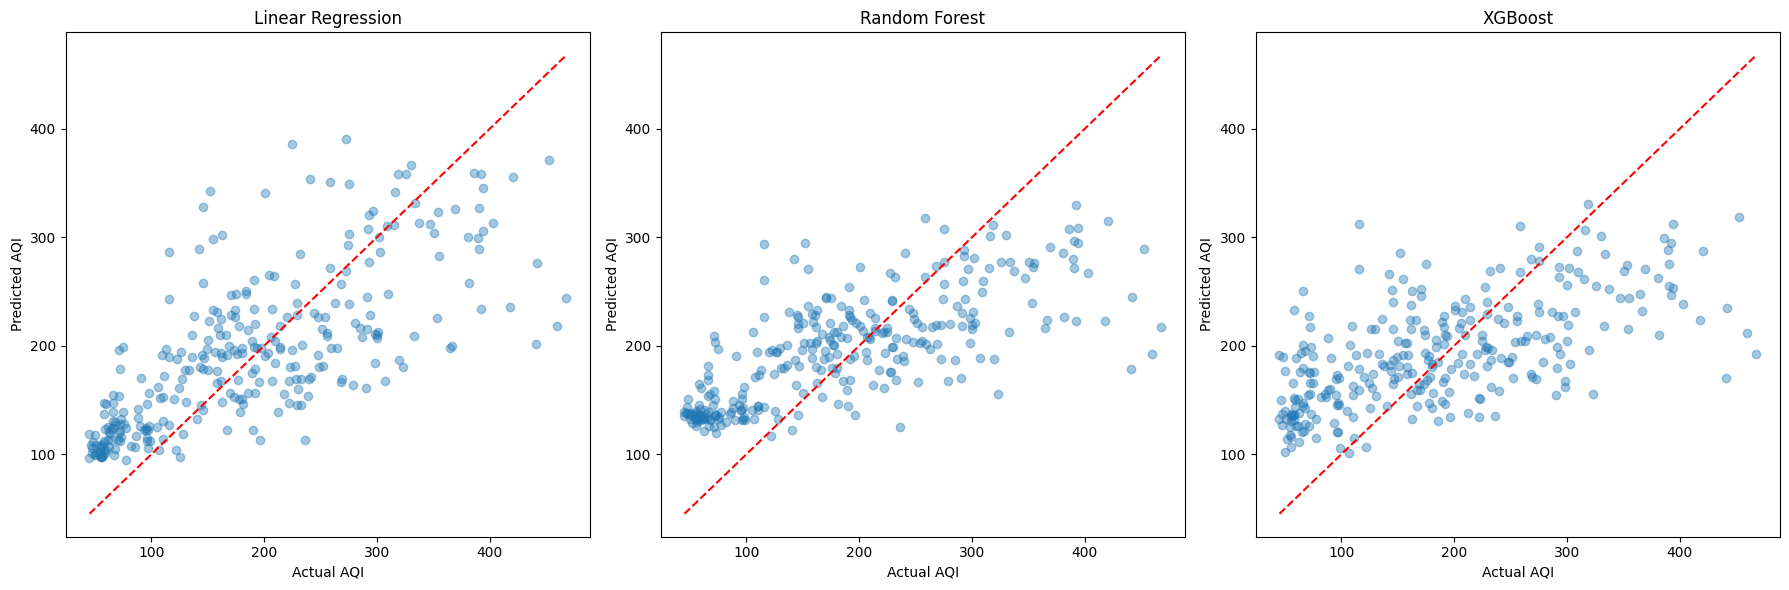

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
for ax, pred, name in zip(axs,
                           [lr_pred, rf_pred, xgb_pred],
                           ['Linear Regression', 'Random Forest', 'XGBoost']):
    ax.scatter(y_test, pred, alpha=0.4)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel('Actual AQI')
    ax.set_ylabel('Predicted AQI')
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [15]:
# TimeSeriesSplit ensures each validation fold comes strictly after its training fold
# Prevents future data from leaking into model training during cross-validation
tscv = TimeSeriesSplit(n_splits=5)

============================================================
CELL 20: HYPERPARAMETER TUNING - RANDOM FOREST
============================================================

In [16]:
rf_param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10]
}

In [17]:
# RandomizedSearchCV samples 20 random hyperparameter combinations
# Uses TimeSeriesSplit instead of standard k-fold to respect temporal ordering
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=20, cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1
)
rf_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchan

============================================================
CELL 21: BEST RANDOM FOREST RESULTS
============================================================

In [18]:
best_rf = rf_random.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("Best RF Parameters:", rf_random.best_params_)
evaluate_model("Random Forest (Tuned)", y_test, y_pred_rf)

Best RF Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}
Random Forest (Tuned):
  RMSE=73.75, MAE=60.29, R2=0.483, MAPE=48.63%


============================================================
CELL 22: HYPERPARAMETER TUNING - XGBOOST
============================================================

In [19]:
xgb_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.9, 1.0]
}

In [20]:
# Same tuning approach for XGBoost — 20 random combinations with TimeSeriesSplit
xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=20, cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1
)
xgb_random.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [200, 400, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

============================================================
CELL 23: BEST XGBOOST RESULTS
============================================================

In [21]:
best_xgb = xgb_random.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print("Best XGB Parameters:", xgb_random.best_params_)
evaluate_model("XGBoost (Tuned)", y_test, y_pred_xgb)

Best XGB Parameters: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
XGBoost (Tuned):
  RMSE=72.61, MAE=59.93, R2=0.499, MAPE=46.91%


# ============================================================
# CELL 24: TUNED VS UNTUNED PLOTS
# ============================================================


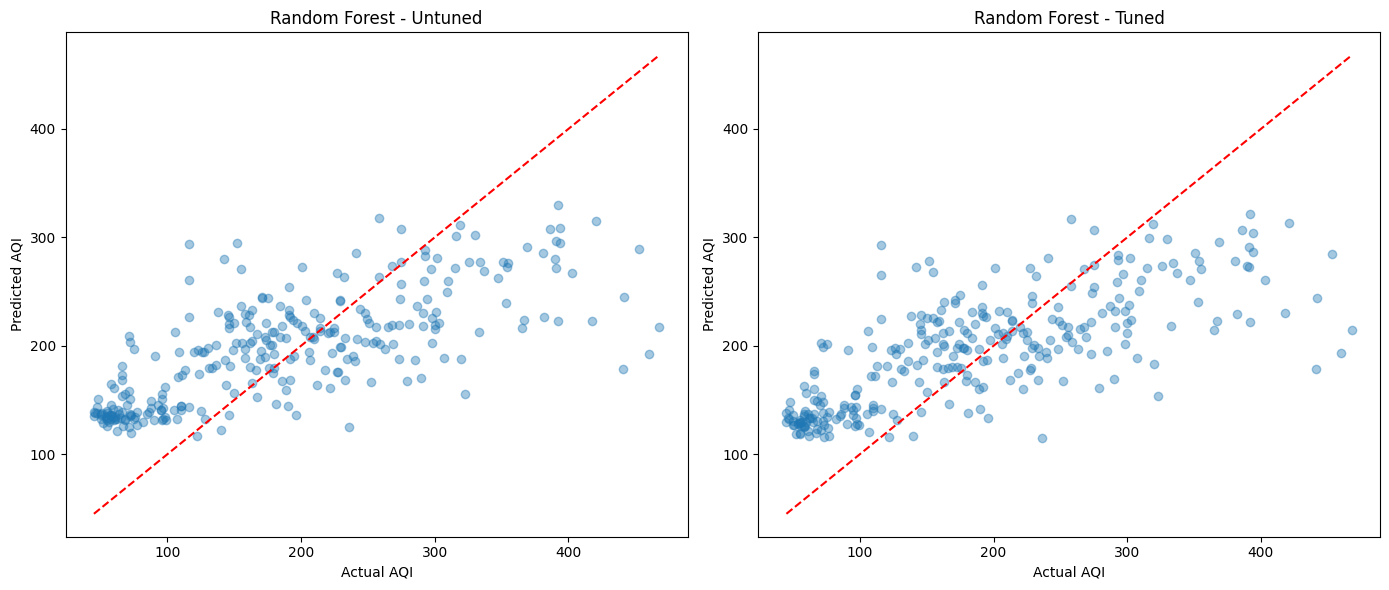

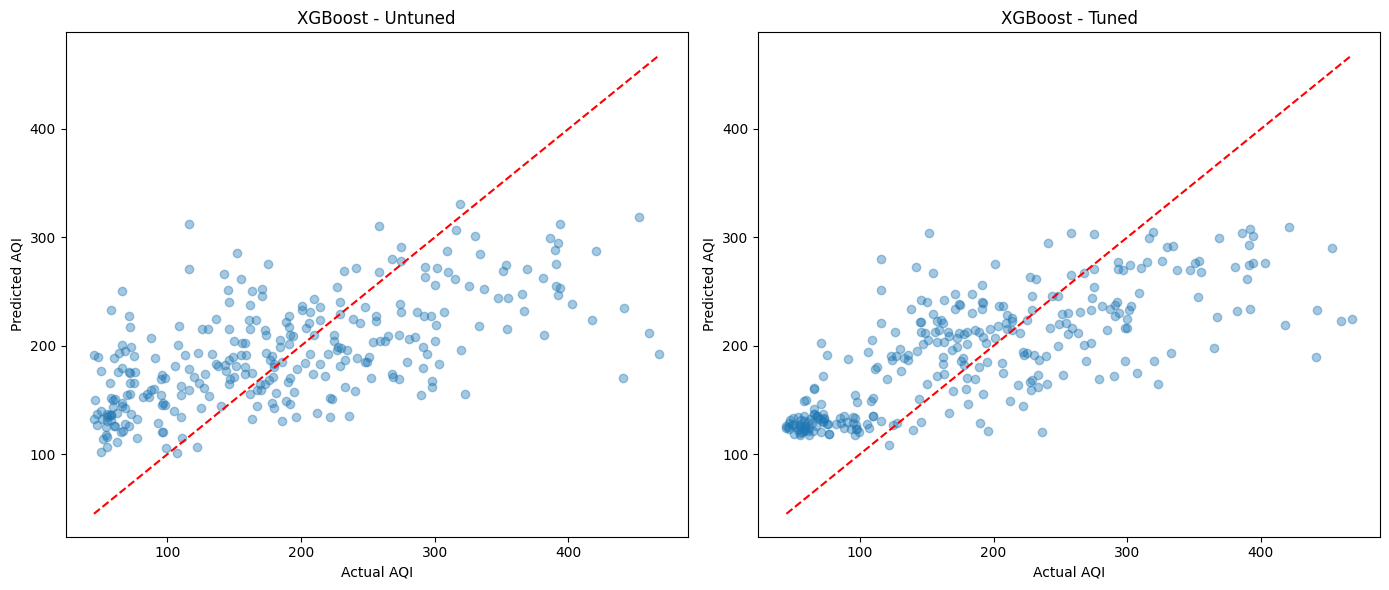

In [22]:
for untuned, tuned, name in [
    (rf_pred, y_pred_rf, 'Random Forest'),
    (xgb_pred, y_pred_xgb, 'XGBoost')
]:
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    for ax, pred, label in zip(axs, [untuned, tuned], ['Untuned', 'Tuned']):
        ax.scatter(y_test, pred, alpha=0.4)
        ax.plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()], 'r--')
        ax.set_title(f'{name} - {label}')
        ax.set_xlabel('Actual AQI')
        ax.set_ylabel('Predicted AQI')
    plt.tight_layout()
    plt.show()

============================================================
CELL 25: CROSS VALIDATION WITH TimeSeriesSplit 
============================================================

In [23]:
models_cv = {
    'Linear Regression': reg,
    'Random Forest (Tuned)': best_rf,
    'XGBoost (Tuned)': best_xgb
}

In [24]:
print("5-Fold TimeSeriesSplit Cross Validation:")
for name, model in models_cv.items():
    scores = cross_validate(
        model, X, y, cv=tscv,
        scoring=['r2',
                 'neg_root_mean_squared_error',
                 'neg_mean_absolute_error']
    )
    print(f"\n{name}")
    print(f"  R2:   {scores['test_r2'].mean():.4f} +/- {scores['test_r2'].std():.4f}")
    print(f"  RMSE: {-scores['test_neg_root_mean_squared_error'].mean():.2f} +/- {scores['test_neg_root_mean_squared_error'].std():.2f}")
    print(f"  MAE:  {-scores['test_neg_mean_absolute_error'].mean():.2f} +/- {scores['test_neg_mean_absolute_error'].std():.2f}")

5-Fold TimeSeriesSplit Cross Validation:

Linear Regression
  R2:   0.3342 +/- 0.1740
  RMSE: 82.57 +/- 15.03
  MAE:  64.04 +/- 11.00

Random Forest (Tuned)
  R2:   0.3555 +/- 0.0909
  RMSE: 81.25 +/- 6.89
  MAE:  64.36 +/- 6.89

XGBoost (Tuned)
  R2:   0.3446 +/- 0.1040
  RMSE: 81.85 +/- 8.09
  MAE:  64.93 +/- 7.27


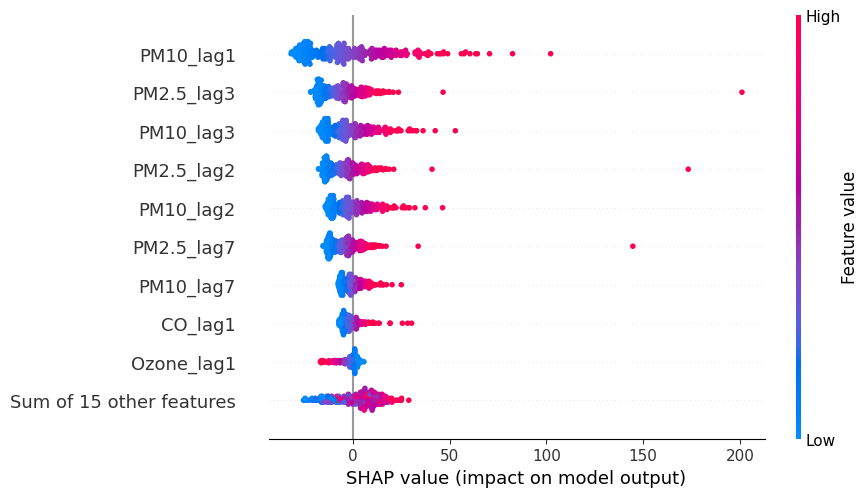

In [25]:
explainer_lr = shap.Explainer(reg, X_train)
shap_values_lr = explainer_lr(X_test)
shap.plots.beeswarm(shap_values_lr)


# ============================================================
# CELL 27: SHAP - RANDOM FOREST
# ============================================================


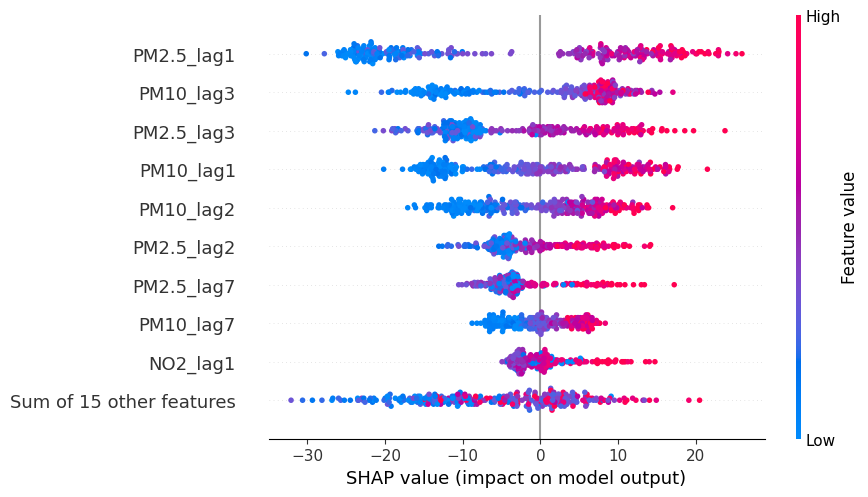

In [26]:
explainer_rf = shap.Explainer(best_rf, X_train)
shap_values_rf = explainer_rf(X_test)
shap.plots.beeswarm(shap_values_rf)


============================================================
CELL 28: SHAP - XGBOOST
============================================================

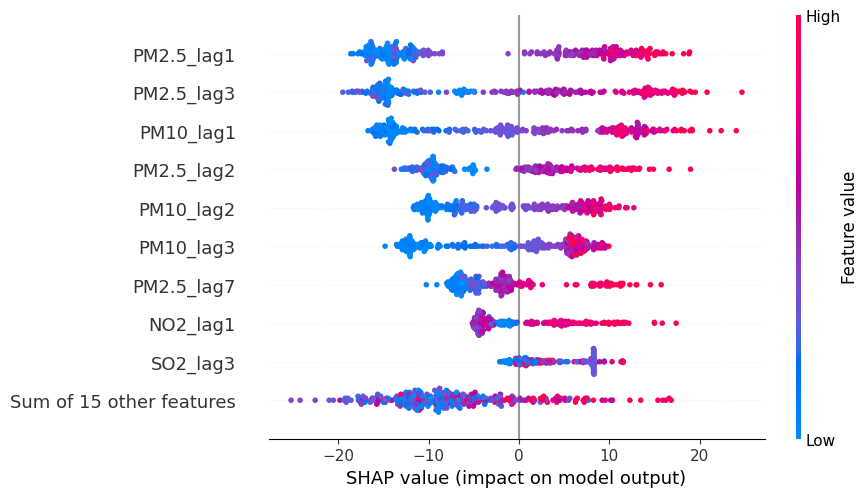

In [27]:
# TreeSHAP computes exact Shapley values efficiently for tree-based models
# Each value shows how much a feature pushed the prediction up or down for that observation
explainer_xgb = shap.Explainer(best_xgb, X_train)
shap_values_xgb = explainer_xgb(X_test)
shap.plots.beeswarm(shap_values_xgb)

============================================================
CELL 29: MEAN SHAP VALUES TABLE (Issue #16)
============================================================

In [28]:
# Average absolute SHAP values across all test predictions for an overall importance ranking
shap_arr = shap_values_xgb.values
shap_summary = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': np.abs(shap_arr).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)
print("Mean Absolute SHAP Values (XGBoost):")
print(shap_summary)

Mean Absolute SHAP Values (XGBoost):
       Feature  Mean |SHAP|
0   PM2.5_lag1    11.661550
12  PM2.5_lag3    11.394960
1    PM10_lag1    10.011709
6   PM2.5_lag2     7.406492
7    PM10_lag2     6.867446
13   PM10_lag3     6.728949
18  PM2.5_lag7     4.865248
2     NO2_lag1     4.485244
15    SO2_lag3     3.641619
19   PM10_lag7     3.065356
10     CO_lag2     2.581134
5   Ozone_lag1     1.836281
23  Ozone_lag7     1.689931
3     SO2_lag1     1.578767
16     CO_lag3     1.518866
4      CO_lag1     1.502592
11  Ozone_lag2     1.467252
20    NO2_lag7     1.352517
9     SO2_lag2     0.994472
17  Ozone_lag3     0.950976
21    SO2_lag7     0.800916
8     NO2_lag2     0.535058
22     CO_lag7     0.486163
14    NO2_lag3     0.408127


============================================================
CELL 31: PROPHET - FIT AND FORECAST
============================================================

In [29]:
prophet_df = df.copy()
# Create proper datetime column
prophet_df['ds'] = df['Date']

In [30]:
# Prophet requires exactly two columns: ds (timestamp) and y (target variable)
prophet_df = df[['Date', 'AQI']].rename(columns={'Date': 'ds', 'AQI': 'y'})

prophet_model = Prophet(
    growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10,
    seasonality_mode='additive'
)

prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=365)
forecast = prophet_model.predict(future)

21:06:27 - cmdstanpy - INFO - Chain [1] start processing
21:06:33 - cmdstanpy - INFO - Chain [1] done processing


prophet_model = Prophet(changepoint_prior_scale=0.05,
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False)


# ============================================================
# CELL 32: PROPHET - FORECAST PLOT
# ============================================================

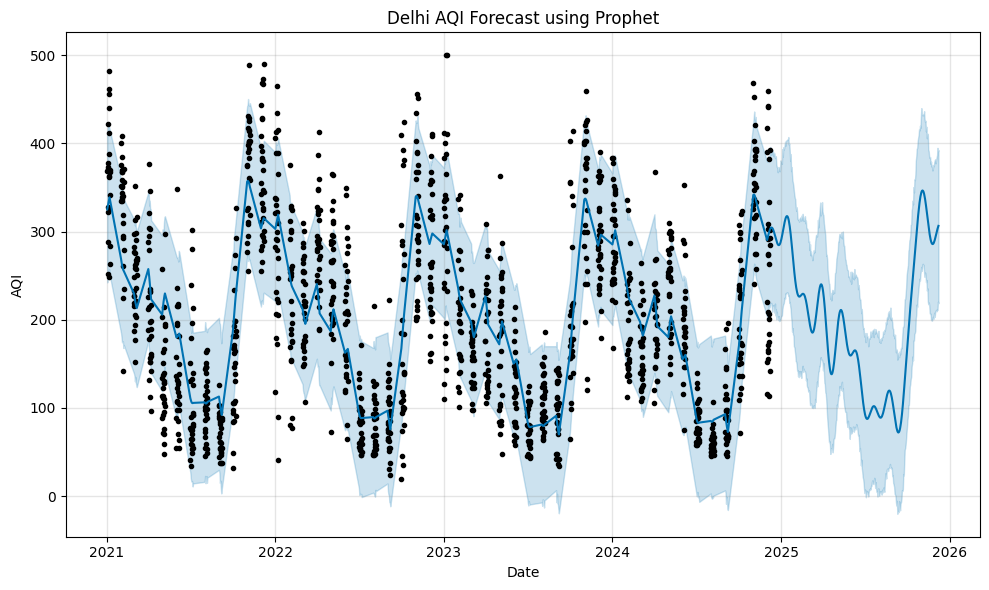

In [31]:
fig = prophet_model.plot(forecast)
ax = fig.gca()
ax.set_title("Delhi AQI Forecast using Prophet")
ax.set_xlabel("Date")
ax.set_ylabel("AQI")
plt.tight_layout()
plt.show()

# ============================================================
# CELL 33: PROPHET - COMPONENTS PLOT
# ============================================================

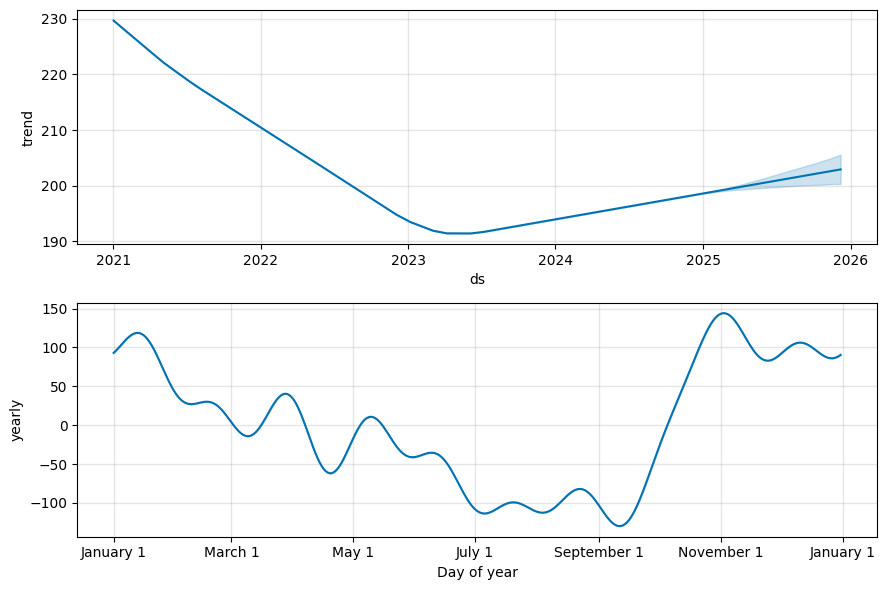

In [32]:
prophet_model.plot_components(forecast)
plt.show()

# ============================================================
# CELL 34: SEASONAL NAIVE BASELINE 
# ============================================================

In [33]:
aqi_vals = df['AQI'].reset_index(drop=True)
train_naive = aqi_vals.iloc[:split]
test_naive  = aqi_vals.iloc[split:].reset_index(drop=True)
# Seasonal naive: predict today's AQI as the value from exactly 365 days ago
# Strong baseline — captures the annual pollution cycle without any modeling
naive_pred  = aqi_vals.shift(365).iloc[split:].reset_index(drop=True)
valid_idx   = naive_pred.dropna().index

In [34]:
naive_rmse = np.sqrt(mean_squared_error(test_naive[valid_idx], naive_pred[valid_idx]))
naive_mae  = mean_absolute_error(test_naive[valid_idx], naive_pred[valid_idx])
print(f"Seasonal Naive Baseline: RMSE={naive_rmse:.2f}, MAE={naive_mae:.2f}")

Seasonal Naive Baseline: RMSE=88.48, MAE=67.86


============================================================
CELL 35: SARIMA BASELINE 
============================================================

In [35]:
# auto_arima selects the best SARIMA order using AIC
# Monthly seasonality (m=12) captures the annual pollution pattern
sarima_model = auto_arima(
    train_naive,
    seasonal=True, m=12,
    suppress_warnings=True,
    stepwise=True,
    error_action='ignore',
    max_p=2, max_q=2,
    max_P=1, max_Q=1,
    max_d=1, max_D=1,
    information_criterion='aic',
    n_jobs=1
)
sarima_pred = sarima_model.predict(n_periods=len(test_naive))
sarima_rmse = np.sqrt(mean_squared_error(test_naive, sarima_pred))
sarima_mae  = mean_absolute_error(test_naive, sarima_pred)
print(f"SARIMA Baseline: RMSE={sarima_rmse:.2f}, MAE={sarima_mae:.2f}")

SARIMA Baseline: RMSE=103.60, MAE=86.52


In [36]:
print("\nForecasting Model Comparison:")
print(f"  Seasonal Naive RMSE: {naive_rmse:.2f}")
print(f"  SARIMA RMSE:         {sarima_rmse:.2f}")
print(f"  Prophet:             validated below against 2025 data")


Forecasting Model Comparison:
  Seasonal Naive RMSE: 88.48
  SARIMA RMSE:         103.60
  Prophet:             validated below against 2025 data


============================================================
CELL 36: 2025 PROPHET VALIDATION 
============================================================

In [39]:
# Actual daily AQI values Oct-Nov 2025 from CPCB Daily AQI Bulletins
# City-level averages aggregated across ~43 Delhi monitoring stations
actual_2025 = [130, 123, 88, 138, 159, 105, 73, 81, 100, 170,
    199, 167, 189, 211, 233, 245, 254, 268, 296, 345,
    351, 353, 305, 275, 292, 309, 301, 294, 279, 373,
    218, 303, 366, 309, 291, 202, 311, 322, 361, 370,
    362, 428, 418, 404, 387, 386, 377, 351, 374, 392,
    391, 364, 370, 391, 382, 353, 327, 377, 369, 305,
    279]  

In [38]:
if len(actual_2025) > 0:
    oct_nov = forecast[
        (forecast['ds'].dt.year == 2025) &
        (forecast['ds'].dt.month.isin([10, 11]))
    ]['yhat'].values

    n = min(len(actual_2025), len(oct_nov))
    actual  = np.array(actual_2025[:n])
    pred_25 = oct_nov[:n]

# Compute validation metrics comparing Prophet forecast against real 2025 observations
    val_rmse = np.sqrt(mean_squared_error(actual, pred_25))
    val_mae  = mean_absolute_error(actual, pred_25)
    hit_300  = np.mean((actual > 300) == (pred_25 > 300))
    hit_400  = np.mean((actual > 400) == (pred_25 > 400))

    print("2025 Prophet Forecast Validation:")
    print(f"  RMSE:          {val_rmse:.2f}")
    print(f"  MAE:           {val_mae:.2f}")
    print(f"  Hit Rate >300: {hit_300:.2%}")
    print(f"  Hit Rate >400: {hit_400:.2%}")
else:
    print("Fill actual_2025 list with observed values from aqicn.org to run validation.")

2025 Prophet Forecast Validation:
  RMSE:          69.60
  MAE:           60.11
  Hit Rate >300: 67.21%
  Hit Rate >400: 95.08%
